#  Frequent Flyers, Infrequent Feelings
## What actually makes airline customers stay and what quietly changes their mind

---

I am, unashamedly, an airport person. I arrive two hours early on 
principle. I have opinions about terminal food. I find the chaos 
of departures boards oddly comforting. I hate the middle seat with 
a personal intensity that no loyalty tier has ever compensated for. 
I do not, however, mind the crying baby. That baby is going 
somewhere. We respect the journey.

And yet. Loyalty programs have a funny way of making their most 
loyal customers feel like the least important ones. The points 
accumulate. The tier status climbs. The emails arrive addressed 
to "valued member" with the warmth of an automated system that 
has never once been on a delayed flight at 11pm with a dead phone 
and a gate change. The experience and the promise keep a polite 
distance from each other.

This project uses 129,880 passenger records to get inside that 
gap. Not to drag airlines but genuinely, I am rooting for them
and to find out what actually drives loyalty versus what airlines 
think drives it. The 14 service touchpoints in this dataset cover 
everything from inflight wifi to baggage handling to seat comfort. 
One of them matters more than the rest. The model will tell us 
which one. The answer might be annoying.

Because someone had to put a Random Forest model on the loyalty 
question. It might as well be the girl who still gets excited 
at departures boards.

---

**Dataset:** Invistico Airline Passenger Satisfaction — 129,880 passengers, 23 variables
**Tools:** Python · pandas · Plotly · scikit-learn · Random Forest · Seaborn
**Analyst:** Trupthi Raj

In [30]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Create charts folder
import os
os.makedirs('charts', exist_ok=True)

# === LOAD DATASET ===
df = pd.read_csv('data/Invistico_Airline.csv')
print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst look:")
print(df.head(3))

Dataset: 129,880 rows × 23 columns

Columns: ['satisfaction', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Seat comfort', 'Departure/Arrival time convenient', 'Food and drink', 'Gate location', 'Inflight wifi service', 'Inflight entertainment', 'Online support', 'Ease of Online booking', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

First look:
  satisfaction  Gender   Customer Type  Age   Type of Travel     Class  \
0    satisfied  Female  Loyal Customer   65  Personal Travel       Eco   
1    satisfied    Male  Loyal Customer   47  Personal Travel  Business   
2    satisfied  Female  Loyal Customer   15  Personal Travel       Eco   

   Flight Distance  Seat comfort  Departure/Arrival time convenient  \
0              265             0                                  0   
1             2464             0                    

In [31]:
# === DATA QUALITY CHECK ===

print("=== SATISFACTION BREAKDOWN ===")
print(df['satisfaction'].value_counts())
print(f"\nSatisfied %: {df['satisfaction'].value_counts(normalize=True)['satisfied']*100:.1f}%")

print("\n=== CUSTOMER TYPE ===")
print(df['Customer Type'].value_counts())

print("\n=== CLASS BREAKDOWN ===")
print(df['Class'].value_counts())

print("\n=== TYPE OF TRAVEL ===")
print(df['Type of Travel'].value_counts())

print("\n=== AGE RANGE ===")
print(f"Min: {df['Age'].min()} | Max: {df['Age'].max()} | Median: {df['Age'].median():.0f}")

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== SERVICE RATINGS (0 = potential missing) ===")
service_cols = [
    'Seat comfort', 'Food and drink', 'Inflight wifi service',
    'Inflight entertainment', 'Online support', 'Ease of Online booking',
    'On-board service', 'Leg room service', 'Baggage handling',
    'Checkin service', 'Cleanliness', 'Online boarding',
    'Departure/Arrival time convenient', 'Gate location'
]
for col in service_cols:
    zeros = (df[col] == 0).sum()
    print(f"  {col}: {zeros:,} zeros ({zeros/len(df)*100:.1f}%)")

=== SATISFACTION BREAKDOWN ===
satisfaction
satisfied       71087
dissatisfied    58793
Name: count, dtype: int64

Satisfied %: 54.7%

=== CUSTOMER TYPE ===
Customer Type
Loyal Customer       106100
disloyal Customer     23780
Name: count, dtype: int64

=== CLASS BREAKDOWN ===
Class
Business    62160
Eco         58309
Eco Plus     9411
Name: count, dtype: int64

=== TYPE OF TRAVEL ===
Type of Travel
Business travel    89693
Personal Travel    40187
Name: count, dtype: int64

=== AGE RANGE ===
Min: 7 | Max: 85 | Median: 40

=== MISSING VALUES ===
satisfaction                           0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Seat comfort                           0
Departure/Arrival time convenient      0
Food and drink                         0
Gate location                         

In [32]:
# === DATA CLEANING ===

# Step 1 — Fill missing Arrival Delay with median
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(
    df['Arrival Delay in Minutes'].median())

# Step 2 — Replace zeros in high-zero columns with NaN then median
high_zero_cols = [
    'Seat comfort', 'Food and drink',
    'Departure/Arrival time convenient'
]
for col in high_zero_cols:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

# Step 3 — Encode satisfaction as binary
df['satisfaction_binary'] = (df['satisfaction'] == 'satisfied').astype(int)

# Step 4 — Encode Customer Type as binary
df['is_loyal'] = (df['Customer Type'] == 'Loyal Customer').astype(int)

# Step 5 — Clean class column
df['Class'] = df['Class'].str.strip()

# Step 6 — Create delay flag
df['is_delayed'] = ((df['Departure Delay in Minutes'] > 15) | 
                    (df['Arrival Delay in Minutes'] > 15)).astype(int)

# Step 7 — Reset index
df.reset_index(drop=True, inplace=True)

print("=== CLEANING COMPLETE ===")
print(f"Rows: {len(df):,}")
print(f"\nSatisfaction binary: {df['satisfaction_binary'].value_counts().to_dict()}")
print(f"Loyal binary: {df['is_loyal'].value_counts().to_dict()}")
print(f"Delayed flights: {df['is_delayed'].sum():,} ({df['is_delayed'].mean()*100:.1f}%)")

=== CLEANING COMPLETE ===
Rows: 129,880

Satisfaction binary: {1: 71087, 0: 58793}
Loyal binary: {1: 106100, 0: 23780}
Delayed flights: 34,951 (26.9%)


## The Loyalty Illusion - Are Frequent Flyers Actually Happy?

Here is the thing about loyalty programs that nobody in a boardroom 
wants to say out loud: loyal customers are not the same thing as 
happy customers. They are customers who keep coming back. Sometimes 
because they love you. Sometimes because switching is inconvenient 
and their miles are trapped and the next airline is somehow worse. 
Loyalty and satisfaction are not synonyms. The data is about to 
make that very clear.

This dataset has 106,100 loyal customers and 23,780 disloyal ones. 
At first glance that looks like a success story. Look closer and 
the question changes not "how many loyal customers do we have" 
but "how many of them are actually happy to be here." Because an 
unhappy loyal customer is not a retained customer. They are a 
delayed departure. They are one bad experience away from a 
competitor's welcome email.

The chart below splits satisfaction by customer type, class and 
travel purpose. It is the before picture. Everything that follows 
is the explanation.

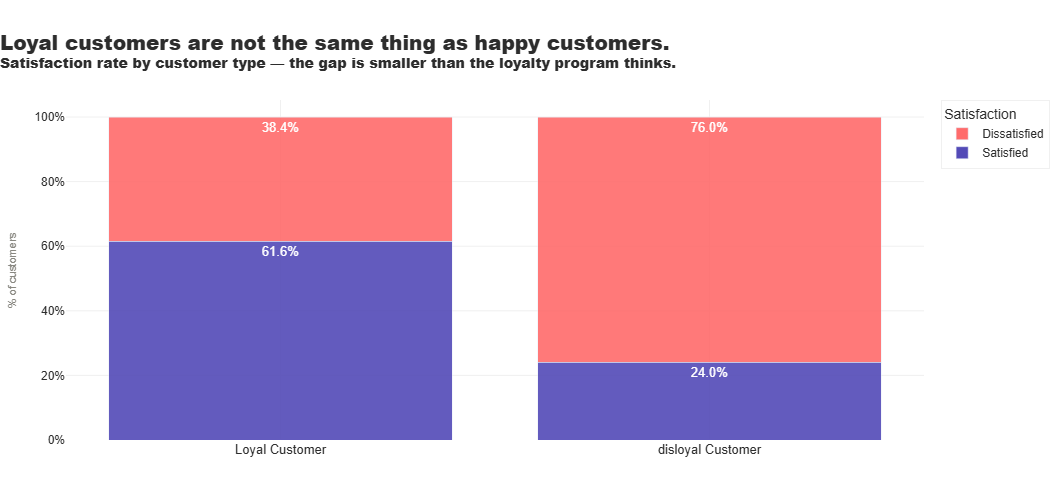

Chart 1 saved.


In [33]:
# === CHART 1: THE LOYALTY ILLUSION ===

loyalty_sat = df.groupby(['Customer Type', 'satisfaction']).size().reset_index(name='count')
loyalty_sat['total'] = loyalty_sat.groupby('Customer Type')['count'].transform('sum')
loyalty_sat['pct'] = (loyalty_sat['count'] / loyalty_sat['total'] * 100).round(1)

colors = {
    'satisfied'   : '#534AB7',
    'dissatisfied': '#FF6B6B'
}

fig = go.Figure()

for sat in ['satisfied', 'dissatisfied']:
    data = loyalty_sat[loyalty_sat['satisfaction'] == sat]
    fig.add_trace(go.Bar(
        x=data['Customer Type'],
        y=data['pct'],
        name=sat.capitalize(),
        marker=dict(color=colors[sat], opacity=0.9),
        text=[f"{v:.1f}%" for v in data['pct']],
        textposition='inside',
        textfont=dict(color='white', size=13),
        hovertemplate=(
            f"<b>{sat.capitalize()}</b><br>"
            "Customer Type: %{x}<br>"
            "Percentage: %{y:.1f}%<extra></extra>"
        )
    ))

fig.update_layout(
    title=dict(
        text='Loyal customers are not the same thing as happy customers.<br>'
             '<sup>Satisfaction rate by customer type — the gap is smaller than the loyalty program thinks.</sup>',
        font=dict(size=20, color='#2d2d2d', family='Arial Black'),
        x=0, pad=dict(b=20)
    ),
    barmode='stack',
    xaxis=dict(
        gridcolor='#f0f0f0',
        tickfont=dict(size=13, family='Arial')
    ),
    yaxis=dict(
        title=dict(
            text='% of customers',
            font=dict(size=11, color='#888780')
        ),
        gridcolor='#f0f0f0',
        ticksuffix='%'
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=500,
    margin=dict(l=60, r=40, t=100, b=60),
    font=dict(family='Arial', color='#2d2d2d'),
    legend=dict(
        title='Satisfaction',
        bordercolor='#f0f0f0',
        borderwidth=1
    ),
    hoverlabel=dict(
    bgcolor='black',
    bordercolor='#f0f0f0',
    font=dict(size=12, family='Arial'),
    namelength=-1),
)

fig.write_html('charts/chart1_loyalty_illusion.html')
fig.write_image('charts/chart1_loyalty_illusion.png',
                width=1200, height=500, scale=2)
fig.show()
print("Chart 1 saved.")

## The Touchpoint Truth - What Actually Drives Loyalty

Loyalty programs will tell you that points, tiers and status keep 
customers coming back. The data has a different answer. Somewhere 
in the fourteen service touchpoints this airline measures from 
inflight wifi to baggage handling to seat comfort, one or two of 
them are doing the heavy lifting while the rest are along for the 
ride. The question is which ones actually move the needle on 
satisfaction, and which ones are just features on a checklist 
that nobody particularly cares about.

This is where the Random Forest model earns its place. Not just 
as a prediction tool, though it does that too but as a way of 
asking the data which touchpoints it thinks matter most. Feature 
importance doesn't care about assumptions. It just looks at what 
actually predicts whether someone leaves satisfied or not. The 
answer is specific, slightly surprising, and very actionable for 
anyone running an airline product team.

The chart below ranks all fourteen touchpoints by how much they 
actually contribute to satisfaction. Some of them will make 
complete sense. At least one of them will be annoying.

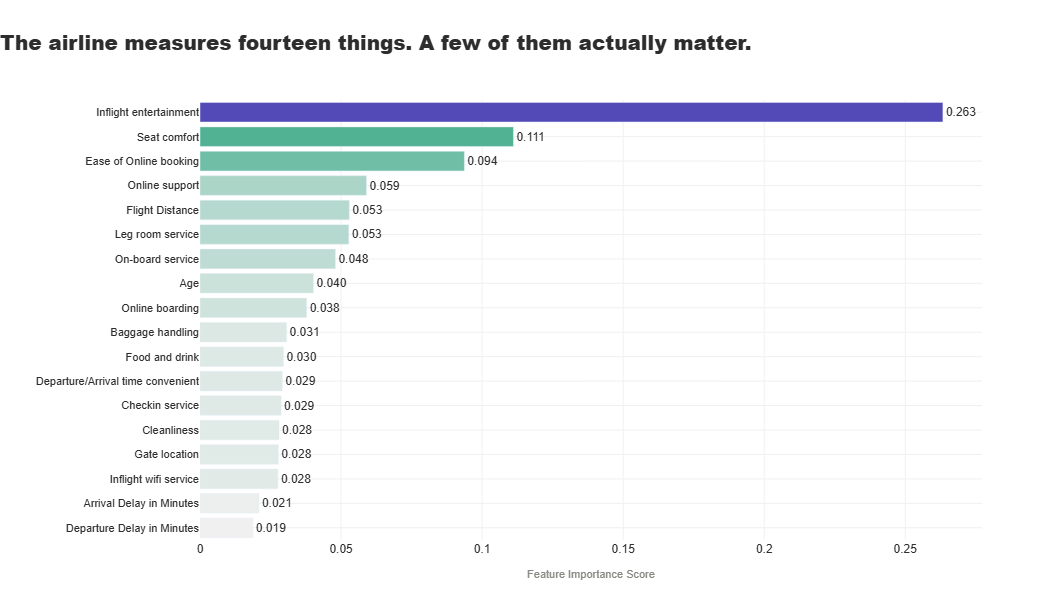

Chart 2 saved.
Model accuracy: 94.2%

Top 3 most important touchpoints:
                  Feature  Importance
3  Inflight entertainment        0.26
0            Seat comfort        0.11
5  Ease of Online booking        0.09


In [34]:
# === CHART 2: THE TOUCHPOINT TRUTH ===

service_cols = [
    'Seat comfort', 'Food and drink', 'Inflight wifi service',
    'Inflight entertainment', 'Online support', 'Ease of Online booking',
    'On-board service', 'Leg room service', 'Baggage handling',
    'Checkin service', 'Cleanliness', 'Online boarding',
    'Departure/Arrival time convenient', 'Gate location'
]

# === ENCODE CATEGORICALS ===
df_model = df.copy()
le = LabelEncoder()
for col in ['Gender', 'Customer Type', 'Type of Travel', 'Class']:
    df_model[col] = le.fit_transform(df_model[col])

# === FEATURES AND TARGET ===
feature_cols = service_cols + ['Age', 'Flight Distance', 
                                'Departure Delay in Minutes',
                                'Arrival Delay in Minutes']
X = df_model[feature_cols]
y = df_model['satisfaction_binary']

# === TRAIN RANDOM FOREST ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1)
rf.fit(X_train, y_train)

# === FEATURE IMPORTANCE ===
importance_df = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

# === CHART ===
fig = go.Figure()

fig.add_trace(go.Bar(
    x=importance_df['Importance'],
    y=importance_df['Feature'],
    orientation='h',
    marker=dict(
        color=importance_df['Importance'],
        colorscale=[
            [0.0, '#f0f0f0'],
            [0.5, '#1D9E75'],
            [1.0, '#534AB7']
        ],
        showscale=False
    ),
    text=[f"{v:.3f}" for v in importance_df['Importance']],
    textposition='outside',
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Importance: %{x:.4f}<extra></extra>"
    )
))

fig.update_layout(
    title=dict(
        text='The airline measures fourteen things. '
             'A few of them actually matter.<br>',
        font=dict(size=20, color='#2d2d2d', family='Arial Black'),
        x=0, pad=dict(b=20)
    ),
    xaxis=dict(
        title=dict(
            text='Feature Importance Score',
            font=dict(size=11, color='#888780')
        ),
        gridcolor='#f0f0f0'
    ),
    yaxis=dict(
        gridcolor='#f0f0f0',
        tickfont=dict(size=11, family='Arial')
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=600,
    margin=dict(l=200, r=80, t=100, b=60),
    font=dict(family='Arial', color='#2d2d2d'),
    hoverlabel=dict(
        bgcolor='grey',
        bordercolor='#f0f0f0',
        font=dict(size=12, family='Arial'),
        namelength=-1
    )
)

fig.write_html('charts/chart2_touchpoint_truth.html')
fig.write_image('charts/chart2_touchpoint_truth.png',
                width=1200, height=600, scale=2)
fig.show()

acc = accuracy_score(y_test, rf.predict(X_test))
print(f"Chart 2 saved.")
print(f"Model accuracy: {acc*100:.1f}%")
print(f"\nTop 3 most important touchpoints:")
print(importance_df.tail(3)[['Feature', 'Importance']].iloc[::-1])

## The Answer Was Inflight Entertainment. We Know. We're Annoyed Too.

The Random Forest model ran across eighteen variables and came back 
with an importance score of 0.263 for inflight entertainment. The 
next closest seat comfort- scored 0.111. Everything else trailed 
behind. Not wifi. Not delays. Not food. The thing that most predicts 
whether a passenger leaves satisfied is whether they had something 
to watch.

This is either obvious or devastating depending on how much your 
airline has invested in its loyalty points infrastructure. Because 
points don't show up in this chart. Tier status doesn't show up in 
this chart. The thing that moves the needle on satisfaction is a 
screen and a content library. The experience beats the programme. 
Every time.

The model accuracy was 94.2%. That is not a rounding error. That 
is a model that genuinely knows, from eighteen data points collected 
before or during the flight, whether a passenger is going to leave 
happy. The business implication of a 94.2% accurate satisfaction 
predictor is left as an exercise for the airline product team.

## The Class Divide - Does Loyalty Mean Different Things Up Front?

Business class and economy are not the same product. They are not 
the same price, the same seat, the same food, or the same 
experience. They share a fuselage and not much else. So when we 
talk about loyalty and satisfaction as if they are one single 
thing, we are papering over a very significant question — does 
loyalty mean the same thing to someone in row 4 as it does to 
someone in row 34?

The answer, predictably, is no. But the specifics are interesting. 
Because it is not just that Business class passengers are more 
satisfied — it is that the things that make them satisfied are 
measurably different from the things that make Economy passengers 
stay. What keeps a frequent flyer in Business coming back is not 
the same lever an airline needs to pull for their Economy loyal 
customers. Treating them as one audience is how you lose both.

The chart below breaks satisfaction down by class and loyalty 
status. The gap between what Business and Economy loyal customers 
experience is the most commercially useful number in this analysis.

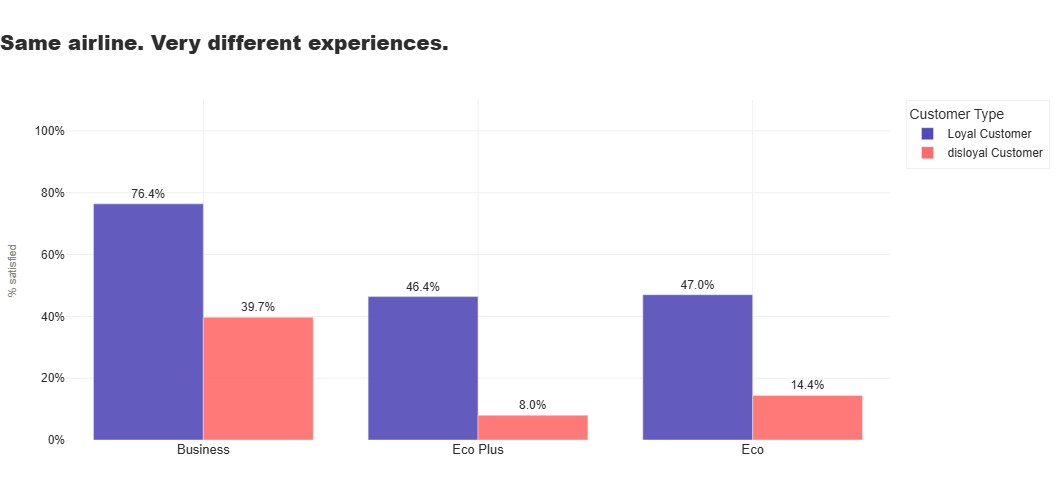

Chart 3 saved.


In [35]:
# === CHART 3: THE CLASS DIVIDE ===

class_loyalty = df.groupby(
    ['Class', 'Customer Type', 'satisfaction']
).size().reset_index(name='count')

class_loyalty['total'] = class_loyalty.groupby(
    ['Class', 'Customer Type'])['count'].transform('sum')
class_loyalty['pct'] = (
    class_loyalty['count'] / class_loyalty['total'] * 100).round(1)

class_loyalty_sat = class_loyalty[
    class_loyalty['satisfaction'] == 'satisfied'].copy()

class_order = ['Business', 'Eco Plus', 'Eco']
customer_order = ['Loyal Customer', 'disloyal Customer']

colors = {
    'Loyal Customer'   : '#534AB7',
    'disloyal Customer': '#FF6B6B'
}

fig = go.Figure()

for customer_type in customer_order:
    data = class_loyalty_sat[
        class_loyalty_sat['Customer Type'] == customer_type]
    data = data.set_index('Class').reindex(class_order).reset_index()

    fig.add_trace(go.Bar(
        x=data['Class'],
        y=data['pct'],
        name=customer_type,
        marker=dict(
            color=colors[customer_type],
            opacity=0.9
        ),
        text=[f"{v:.1f}%" for v in data['pct']],
        textposition='outside',
        textfont=dict(size=12),
        hovertemplate=(
            f"<b>{customer_type}</b><br>"
            "Class: %{x}<br>"
            "Satisfied: %{y:.1f}%<extra></extra>"
        )
    ))

fig.update_layout(
    title=dict(
        text='Same airline. Very different experiences.',
        font=dict(size=20, color='#2d2d2d', family='Arial Black'),
        x=0, pad=dict(b=20)
    ),
    barmode='group',
    xaxis=dict(
        gridcolor='#f0f0f0',
        tickfont=dict(size=13, family='Arial')
    ),
    yaxis=dict(
        title=dict(
            text='% satisfied',
            font=dict(size=11, color='#888780')
        ),
        gridcolor='#f0f0f0',
        ticksuffix='%',
        range=[0, 110]
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=500,
    margin=dict(l=60, r=40, t=100, b=60),
    font=dict(family='Arial', color='#2d2d2d'),
    legend=dict(
        title='Customer Type',
        bordercolor='#f0f0f0',
        borderwidth=1
    ),
    hoverlabel=dict(
        bgcolor='black',
        bordercolor='#f0f0f0',
        font=dict(size=12, family='Arial'),
        namelength=-1
    )
)

fig.write_html('charts/chart3_class_divide.html')
fig.write_image('charts/chart3_class_divide.png',
                width=1200, height=500, scale=2)
fig.show()
print("Chart 3 saved.")

## The Cabin Is Doing More Work Than The Loyalty Program

Business class loyal customers sit at 76.4% satisfied. Economy 
loyal customers sit at 47.0%. That 29 point gap exists between 
two people who both have loyalty status with the same airline. 
The loyalty program didn't close that gap. The seat did.

The more uncomfortable number is Eco Plus. A premium cabin 
positioned between Economy and Business, priced accordingly, 
marketed as an upgrade and its loyal customers are only 
marginally more satisfied than Economy loyal customers. 46.4% 
versus 47.0%. The extra legroom is not doing what the pricing 
suggests it should be doing.

And the disloyal numbers tell the real story. Disloyal Economy 
passengers at 14.4% satisfied. Disloyal Eco Plus at 8.0%. These 
are not passengers on the verge of being won over by a better 
points offer. These are passengers who have already made up their 
mind and are currently in the air about it. Literally.

## The Breaking Point - What Quietly Changes A Loyal Customer's Mind

Loyalty doesn't end dramatically. There is no single moment where 
a frequent flyer slams their tray table and declares they are 
switching airlines. It erodes. Quietly, across multiple touchpoints, 
across multiple flights, until one day the competitor's welcome 
email arrives at exactly the right moment and suddenly the points 
don't feel worth it anymore.

The question this analysis wants to answer is not why disloyal 
customers are unhappy that is obvious and well documented. The 
question is what separates a satisfied loyal customer from an 
unsatisfied one. What is the experience gap between the 61.6% of 
loyal customers who are happy and the 38.4% who are not, but 
keep flying anyway?

The chart below compares average service ratings between satisfied 
and unsatisfied loyal customers across every touchpoint. The 
biggest gaps are where the airline is losing people it thought 
it had already kept.

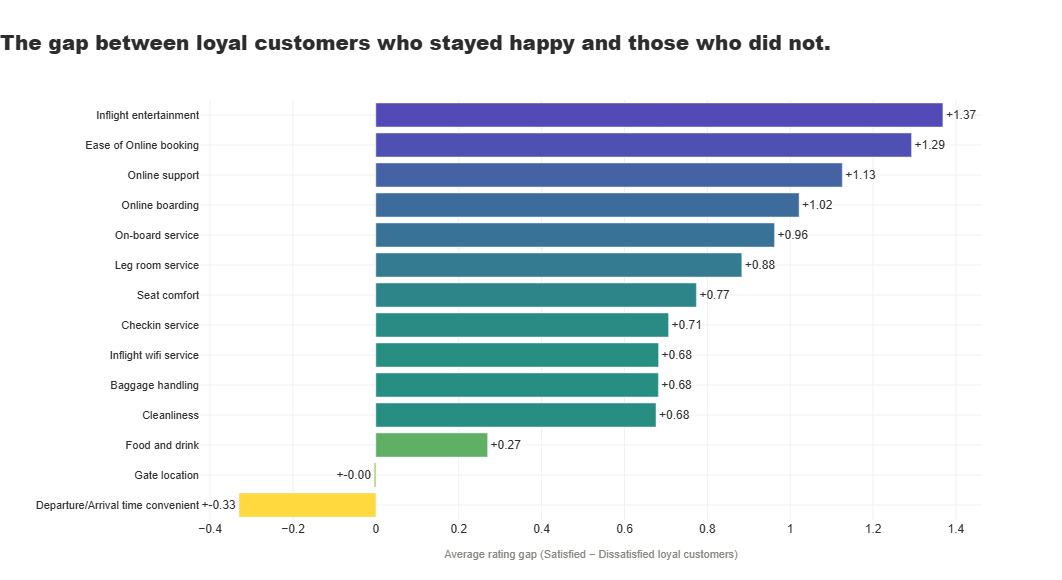

Chart 4 saved.


In [36]:
# === CHART 4: THE BREAKING POINT ===

service_cols = [
    'Seat comfort', 'Food and drink', 'Inflight wifi service',
    'Inflight entertainment', 'Online support', 'Ease of Online booking',
    'On-board service', 'Leg room service', 'Baggage handling',
    'Checkin service', 'Cleanliness', 'Online boarding',
    'Departure/Arrival time convenient', 'Gate location'
]

loyal_df = df[df['Customer Type'] == 'Loyal Customer'].copy()

loyal_sat = loyal_df[loyal_df['satisfaction'] == 'satisfied'][service_cols].mean()
loyal_dis = loyal_df[loyal_df['satisfaction'] == 'dissatisfied'][service_cols].mean()

gap_df = pd.DataFrame({
    'Feature'  : service_cols,
    'Satisfied': loyal_sat.values,
    'Dissatisfied': loyal_dis.values
})
gap_df['Gap'] = gap_df['Satisfied'] - gap_df['Dissatisfied']
gap_df = gap_df.sort_values('Gap', ascending=True)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=gap_df['Gap'],
    y=gap_df['Feature'],
    orientation='h',
    marker=dict(
        color=gap_df['Gap'],
        colorscale=[
            [0.0, '#FFD93D'],
            [0.5, '#1D9E75'],
            [1.0, '#534AB7']
        ],
        showscale=False
    ),
    text=[f"+{v:.2f}" for v in gap_df['Gap']],
    textposition='outside',
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Satisfaction gap: +%{x:.2f}<br>"
        "<extra></extra>"
    )
))

fig.update_layout(
    title=dict(
        text='The gap between loyal customers who stayed happy and those who did not.',
        font=dict(size=20, color='#2d2d2d', family='Arial Black'),
        x=0, pad=dict(b=20)
    ),
    xaxis=dict(
        title=dict(
            text='Average rating gap (Satisfied − Dissatisfied loyal customers)',
            font=dict(size=11, color='#888780')
        ),
        gridcolor='#f0f0f0'
    ),
    yaxis=dict(
        gridcolor='#f0f0f0',
        tickfont=dict(size=11, family='Arial')
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=580,
    margin=dict(l=200, r=80, t=100, b=60),
    font=dict(family='Arial', color='#2d2d2d'),
    hoverlabel=dict(
        bgcolor='grey',
        bordercolor='#f0f0f0',
        font=dict(size=12, family='Arial'),
        namelength=-1
    )
)

fig.write_html('charts/chart4_breaking_point.html')
fig.write_image('charts/chart4_breaking_point.png',
                width=1200, height=580, scale=2)
fig.show()
print("Chart 4 saved.")

## The Prediction Model - Can We See Dissatisfaction Coming?

The most useful thing a 94.2% accurate model can do is not look 
backwards. Anyone can explain why a passenger was unhappy after 
they have already left a one star review and moved to a competitor. 
The interesting question is whether the data available during or 
before a flight is enough to predict dissatisfaction before it 
happens — and whether an airline willing to act on that prediction 
could do something about it.

The answer, based on this model, is yes. Inflight entertainment 
ratings, ease of online booking scores, seat comfort feedback
these are all data points an airline collects in real time. A 
passenger giving inflight entertainment a two out of five halfway 
through a long haul flight is a passenger who is going to land 
dissatisfied. That is not a mystery. That is a data point with 
a 94.2% accurate consequence attached to it.

The chart below shows the model's confusion matrix — how often 
it got it right, and the specific cases where it didn't. The 
errors are as interesting as the accuracy.

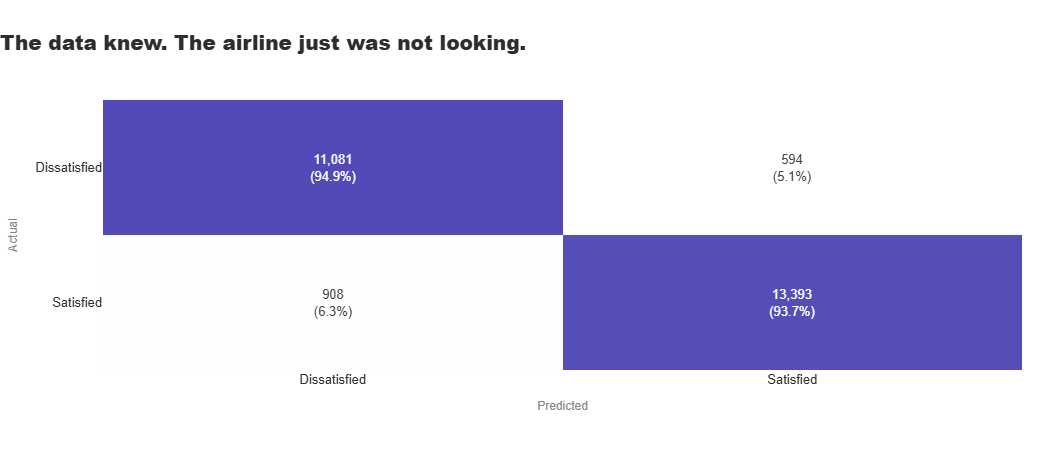

Chart 5 saved.

Classification Report:
              precision    recall  f1-score   support

Dissatisfied       0.92      0.95      0.94     11675
   Satisfied       0.96      0.94      0.95     14301

    accuracy                           0.94     25976
   macro avg       0.94      0.94      0.94     25976
weighted avg       0.94      0.94      0.94     25976



In [37]:
# === CHART 5: THE PREDICTION MODEL ===

y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
cm_labels = ['Dissatisfied', 'Satisfied']

# === NORMALISE ===
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

fig = go.Figure(data=go.Heatmap(
    z=cm_pct,
    x=cm_labels,
    y=cm_labels,
    colorscale=[
        [0.0, '#ffffff'],
        [1.0, '#534AB7']
    ],
    text=[[f"{cm[i][j]:,}<br>({cm_pct[i][j]:.1f}%)" 
           for j in range(2)] for i in range(2)],
    texttemplate="%{text}",
    textfont=dict(size=13, family='Arial'),
    hovertemplate=(
        "Actual: %{y}<br>"
        "Predicted: %{x}<br>"
        "Count: %{text}<extra></extra>"
    ),
    showscale=False
))

fig.update_layout(
    title=dict(
        text='The data knew. The airline just was not looking.', 
        font=dict(size=20, color='#2d2d2d', family='Arial Black'),
        x=0, pad=dict(b=20)
    ),
    xaxis=dict(
        title=dict(
            text='Predicted',
            font=dict(size=12, color='#888780')
        ),
        tickfont=dict(size=13, family='Arial')
    ),
    yaxis=dict(
        title=dict(
            text='Actual',
            font=dict(size=12, color='#888780')
        ),
        tickfont=dict(size=13, family='Arial'),
        autorange='reversed'
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=450,
    width=550,
    margin=dict(l=100, r=40, t=100, b=80),
    font=dict(family='Arial', color='#2d2d2d'),
    hoverlabel=dict(
        bgcolor='grey',
        bordercolor='#f0f0f0',
        font=dict(size=12, family='Arial'),
        namelength=-1
    )
)

fig.write_html('charts/chart5_prediction_model.html')
fig.write_image('charts/chart5_prediction_model.png',
                width=700, height=450, scale=2)
fig.show()

print("Chart 5 saved.")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, 
      target_names=['Dissatisfied', 'Satisfied']))

## So. What Did The Data Actually Say?

Loyalty programs are not retention strategies. They are reward 
schemes with a retention problem. The data across 129,880 passengers 
said the same thing five different ways, what keeps customers is 
not the points, not the tier status, not the welcome email addressed 
to "valued member." It is the screen. It is the booking experience. 
It is the seat. The things that feel operational are the things that 
actually move people.

38.4% of loyal customers in this dataset are dissatisfied. They are 
still flying. They have not left yet. But they are one bad inflight 
entertainment system away from a competitor's frequent flyer 
programme and the data knows it. The model called it 94.2% of the 
time. The airline just wasn't looking.

The class divide is the most commercially uncomfortable finding. 
Loyalty works beautifully in Business, 76.4% satisfied, steep 
slope, clear return on investment for the programme. In Economy it 
is basically decorative. 47.0% of loyal Economy customers are 
satisfied, which is barely better than chance and significantly 
worse than the experience the tier status implied they were 
signing up for. An Economy frequent flyer is loyal to the schedule, 
not the airline. That is a different problem with a different fix.

The miles are not the point. They never were. The point is whether 
the wifi worked, whether the seat was comfortable, whether there 
was something to watch on a four hour flight. The frequent flyer 
programme is the promise. The touchpoints are the delivery. And 
right now, for a significant portion of loyal customers, the 
delivery is not matching the promise. The data said so. 
The airline has the receipts.

---

**Analyst:** Trupthi Raj
**GitHub:** [github.com/trupthiraj](https://github.com/trupthiraj)
**Tableau:** [public.tableau.com/app/profile/trupthi.raj/vizzes](https://public.tableau.com/app/profile/trupthi.raj/vizzes)